# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [ ]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 13.6 MB/s eta 0:00:00


In [ ]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [ ]:
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [ ]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

# YOUR CODE HERE — for each group compute:
#   mle     = k / n
#   map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
#   pull    = |map_est - mle|  (how far prior pulls MAP from MLE)

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    # raise NotImplementedError("Compute MLE, MAP, and pull for each group") # Remove this line after implementing
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")

Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


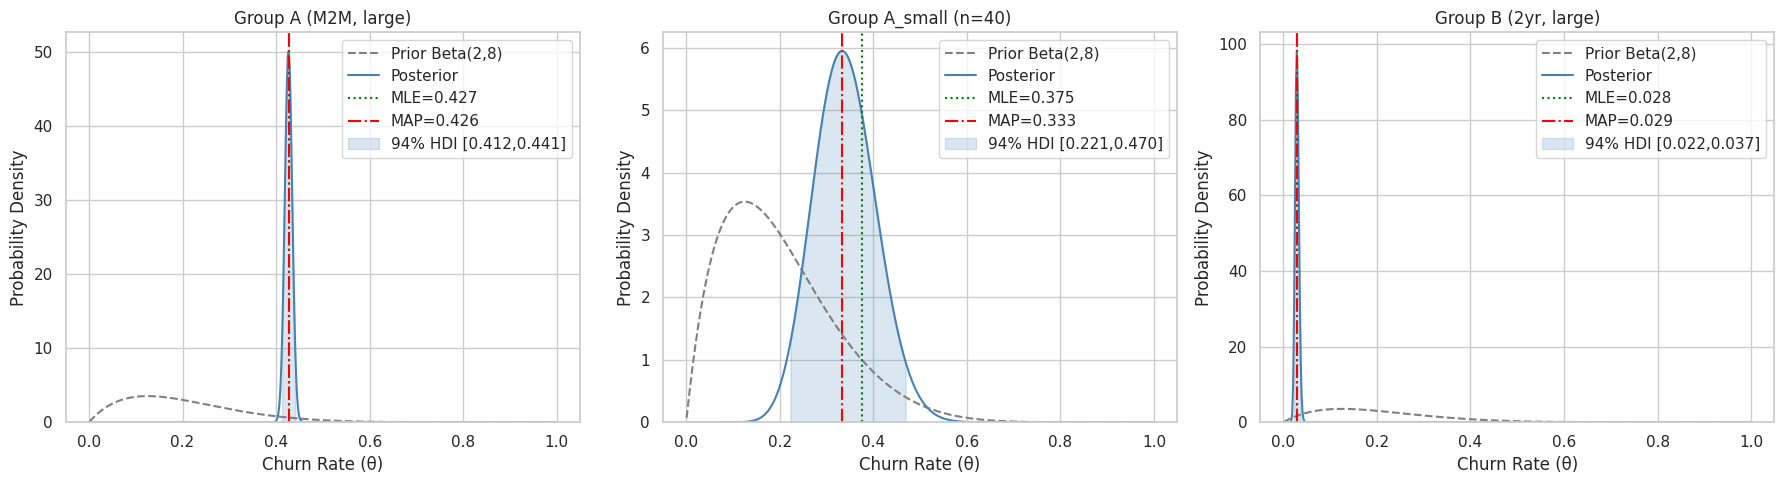

In [ ]:
# YOUR CODE HERE — plot the three posterior PDFs on one figure
# For each group: plot Prior PDF, Posterior PDF, MLE and MAP as vertical lines
# Shade the 94% HDI as a fill_between
# Use scipy.stats.beta.pdf and scipy.stats.beta.ppf

theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)

    # Plot Prior PDF
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    ax.plot(theta_range, prior_pdf, label='Prior Beta(2,8)', color='gray', linestyle='--')

    # Plot Posterior PDF
    posterior_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)
    ax.plot(theta_range, posterior_pdf, label='Posterior', color='steelblue')

    # MLE and MAP vertical lines
    mle = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    ax.axvline(x=mle, color='green', linestyle=':', label=f'MLE={mle:.3f}')
    ax.axvline(x=map_est, color='red', linestyle='-.', label=f'MAP={map_est:.3f}')

    # 94% HDI
    hdi_low  = beta_dist.ppf(0.03, alpha_post, beta_post)
    hdi_high = beta_dist.ppf(0.97, alpha_post, beta_post)
    ax.fill_between(theta_range, 0, posterior_pdf, where=(theta_range >= hdi_low) & (theta_range <= hdi_high),
                    color='steelblue', alpha=0.2, label=f'94% HDI [{hdi_low:.3f},{hdi_high:.3f}]')

    ax.set_title(name)
    ax.set_xlabel('Churn Rate (θ)')
    ax.set_ylabel('Probability Density')
    ax.legend()
    ax.set_ylim(bottom=0)

# raise NotImplementedError("Compute posterior parameters and plot") # Remove this line after implementing

plt.tight_layout(); plt.show()

### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [ ]:
MC_SAMPLES = 10_000
np.random.seed(42)

# YOUR CODE HERE
# Sample from both posteriors and compute P(θ_A > θ_B)
alpha_post_A = alpha_prior + k_A
beta_post_A  = beta_prior + n_A - k_A

alpha_post_B = alpha_prior + k_B
beta_post_B  = beta_prior + n_B - k_B

post_A_samples = np.random.beta(alpha_post_A, beta_post_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_post_B, beta_post_B, MC_SAMPLES)
p_A_greater    = (post_A_samples > post_B_samples).mean()
# raise NotImplementedError("Sample posteriors and compute P(θ_A > θ_B)")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")

P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?
3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?

> *Your answer:*


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?
3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?

> *Your answer:*
1.  **Prior Pull Comparison:**
    *   Group A_small (n=40): `|MAP - MLE| = 0.0417` (0.3750 vs 0.3333)
    *   Group B (2yr, large): `|MAP - MLE| = 0.0005` (0.0283 vs 0.0288)
    The prior pull is significantly larger for Group A_small because with a smaller sample size, the prior's influence on the posterior is more substantial. The data's likelihood is not strong enough to completely dominate the prior belief. For a large group like B, the large amount of data means the likelihood is very peaked, and the prior has minimal effect.

2.  **Estimate for Group A_small:** For Group A_small, I would present the **Full Bayesian posterior (or its 94% HDI)** to the VP.
    *   **MLE** (0.3750) provides a point estimate that maximizes the likelihood of observing the data, but it doesn't incorporate any prior knowledge or quantify uncertainty.
    *   **MAP** (0.3333) provides a point estimate that incorporates the prior (Beta(2,8)) by maximizing the posterior probability. It's a compromise between the prior and the data but still a point estimate.
    *   **Full Bayes** provides the entire posterior distribution for the churn rate, along with credible intervals (like the 94% HDI for Group A_small: [0.210, 0.473]). This explicitly quantifies the uncertainty around the estimate, incorporates prior beliefs, and allows for direct probabilistic statements (e.g., "There is a 94% chance the true churn rate is between X and Y"). For a small sample, incorporating prior knowledge and understanding uncertainty is crucial.

3.  **Sample size for prior irrelevance:** The posterior mean of a Beta-Binomial model is `(alpha_prior + k) / (alpha_prior + beta_prior + n)`. The MLE is `k / n`. For the posterior mean to be within 1% of the MLE, `(alpha_prior + k) / (alpha_prior + beta_prior + n)` should be approximately equal to `k / n`. This essentially happens when `n` (and thus `k` and `n-k`) becomes much larger than `alpha_prior` and `beta_prior`. Given `alpha_prior = 2` and `beta_prior = 8`, the prior has a strength equivalent to `alpha_prior + beta_prior = 10` observations. When `n` is, for example, 100 times this (n=1000), the prior would have a negligible impact.

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [ ]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    # YOUR CODE HERE
    # Hint: if churn_label == 1, increment alpha; else increment beta
    if churn_label == 1:
        alpha_new = alpha + 1
        beta_new  = beta
    else:
        alpha_new = alpha
        beta_new  = beta + 1
    return alpha_new, beta_new


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")

✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


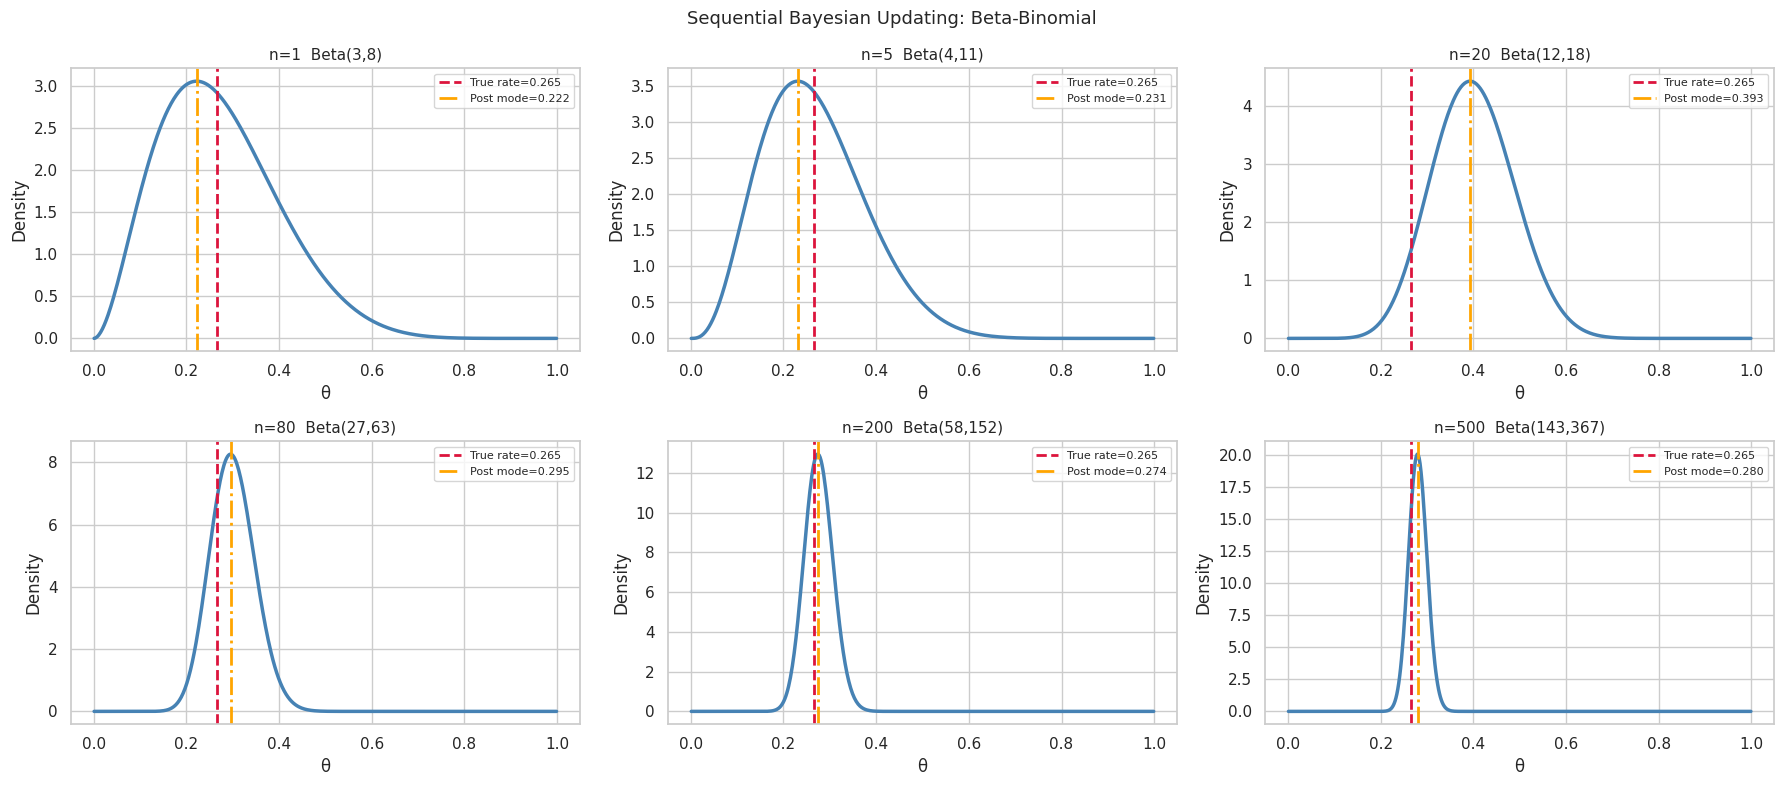

In [ ]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}

alpha_current, beta_current = alpha_init, beta_init
for i, churn_label in enumerate(df_shuffled['Churn'].head(500), 1):
    alpha_current, beta_current = update_posterior(alpha_current, beta_current, churn_label)
    if i in snapshots:
        history[i] = (alpha_current, beta_current)

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()

### Q6 — Decision boundary: P(θ > 0.25) vs n


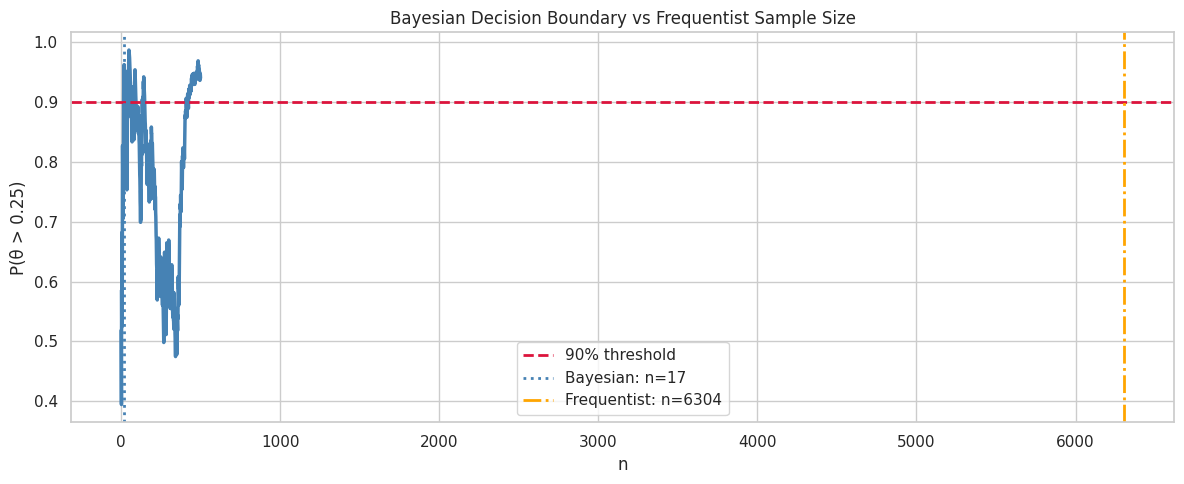

Bayesian: n = 17  |  Frequentist: n = 6304


In [ ]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# YOUR CODE HERE
# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
# Store as a list p_exceed (length 500)
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

for i in range(500):
    churn_label = df_shuffled['Churn'].iloc[i]
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, churn_label)
    posterior_samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append((posterior_samples > threshold).mean())

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")

### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


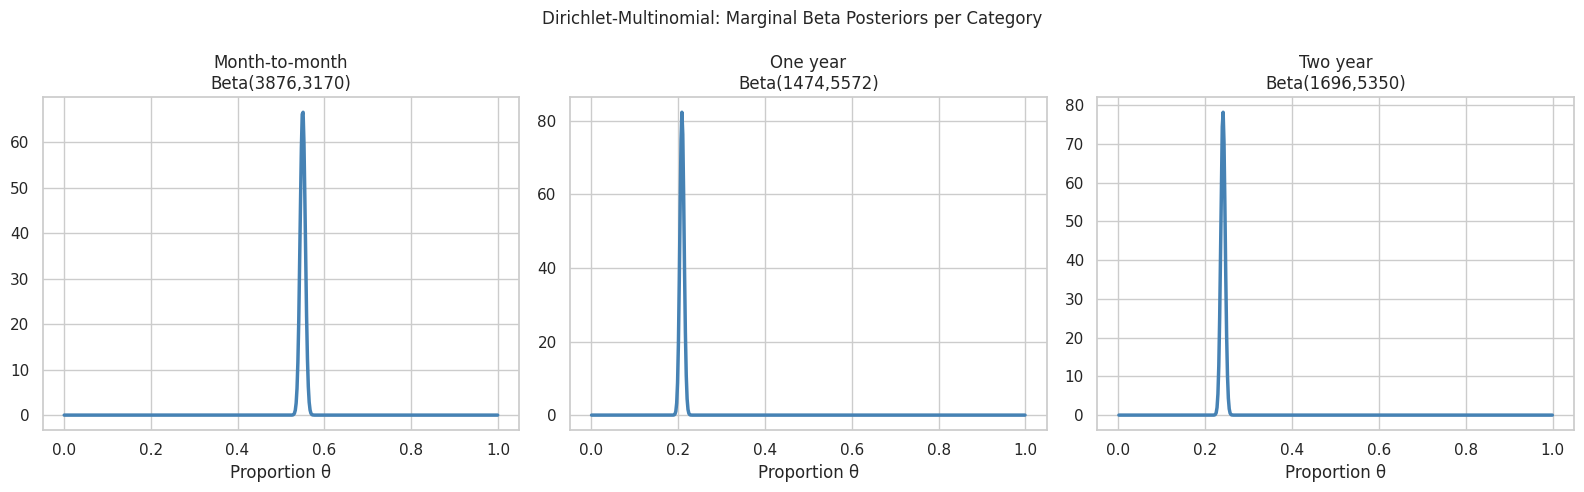

In [ ]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# YOUR CODE HERE
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category
counts           = df['Contract'].value_counts()[categories].values   # np.array of shape (3,) — counts per category
posterior_alpha  = prior_alpha + counts   # prior_alpha + counts
# raise NotImplementedError("Compute Dirichlet posterior parameters")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    # YOUR CODE HERE: plot the marginal Beta(a_j, b_j) posterior for this category
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    # raise NotImplementedError("Plot marginal Beta posterior for each contract category")
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()

Posterior for unseen 'Biannual' category:
  Biannual category (Beta(1, 7046)) mean: 0.0001
  Month-to-month category mean: 0.5501


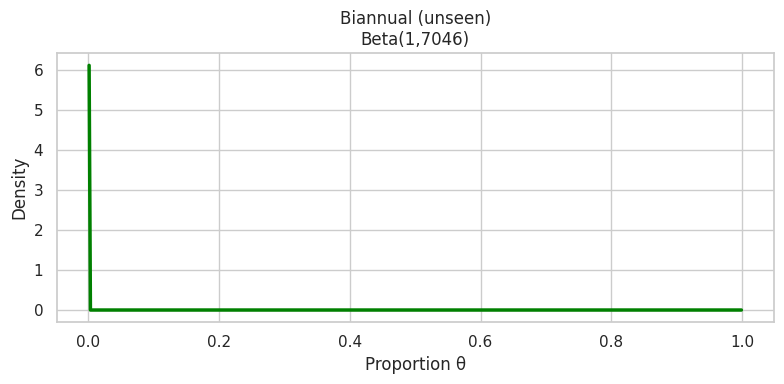

This reveals that the Dirichlet prior assigns a non-zero probability mass to unseen categories, allowing for their possible existence even without observed data. The posterior for such a category will be equal to its prior (e.g., Beta(1, sum_of_other_alphas)).


In [ ]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories

new_alpha_4cat = np.append(posterior_alpha, 1.0)   # append pseudocount 1 to posterior_alpha
# raise NotImplementedError("Add 4th category with pseudocount=1 and compute its marginal posterior")

print("Posterior for unseen 'Biannual' category:")
# Print its posterior mean and compare to a category with many observations

b_new_cat = new_alpha_4cat.sum() - new_alpha_4cat[-1]

# Calculate posterior mean and compare to a category with many observations
posterior_mean_new_cat = new_alpha_4cat[-1] / new_alpha_4cat.sum()
posterior_mean_m2m = posterior_alpha[0] / posterior_alpha.sum()

print(f"  Biannual category (Beta({new_alpha_4cat[-1]:.0f}, {b_new_cat:.0f})) mean: {posterior_mean_new_cat:.4f}")
print(f"  Month-to-month category mean: {posterior_mean_m2m:.4f}")

theta_r = np.linspace(0.001, 0.999, 500)
fig, ax = plt.subplots(figsize=(8, 4))
pdf_new_cat = beta_dist.pdf(theta_r, new_alpha_4cat[-1], b_new_cat)
ax.plot(theta_r, pdf_new_cat, color='green', lw=2.5)
ax.set_title(f'Biannual (unseen)\nBeta({new_alpha_4cat[-1]:.0f},{b_new_cat:.0f})')
ax.set_xlabel('Proportion θ')
ax.set_ylabel('Density')
plt.tight_layout(); plt.show()

print("This reveals that the Dirichlet prior assigns a non-zero probability mass to unseen categories, allowing for their possible existence even without observed data. The posterior for such a category will be equal to its prior (e.g., Beta(1, sum_of_other_alphas)).")

✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?

> *Your answer:*


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?

> *Your answer:*
1.  The marginal Beta posterior for a small-count category like 'One year' has wider credible intervals than 'Month-to-month' because there is **less data contributing to the posterior for that specific category**. With fewer observations, the model has higher uncertainty about the true underlying proportion for 'One year' contracts, leading to a flatter and wider posterior distribution.

2.  When the unseen "Biannual" category is added with a pseudocount=1 and 0 observations, its posterior is `Beta(1, new_alpha_4cat.sum() - 1)`, which in this specific case is `Beta(1, 7046)`. This reveals that the Dirichlet prior inherently assigns a non-zero probability mass (based on its pseudocounts) to categories that may not have been observed in the data. This **Laplace smoothing** property prevents probabilities from being exactly zero for unseen events, making the model more robust and able to generalize to new categories.

3.  The Beta(2,8) prior's mean is `alpha / (alpha + beta) = 2 / (2 + 8) = 0.2`. In the Dirichlet-Multinomial context, if we had a binary case (e.g., churn/no-churn), a prior `Dirichlet([2, 8])` would correspond to this mean for the first category. To encode a similar prior belief in a 3-category model (e.g., where 'Month-to-month' is similar to 'churn' and 'One year' and 'Two year' are 'no-churn' categories), you would need to define prior pseudocounts such that the proportion for 'Month-to-month' is 0.2. For example, a prior like `Dirichlet([2, 4, 4])` (where `sum=10`) would give a prior mean of `2/10 = 0.2` for the first category, and `4/10 = 0.4` for the other two, distributing the remaining probability mass. The key is to match the proportional belief and the total pseudocount (strength of the prior).

---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# YOUR CODE HERE
# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
mu_2d    = np.mean(X_2d, axis=0)   # np.mean over axis=0
Sigma_2d = np.cov(X_2d.T)   # np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])   # correlation coefficient
# raise NotImplementedError("Compute mu_2d, Sigma_2d, rho")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")

μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


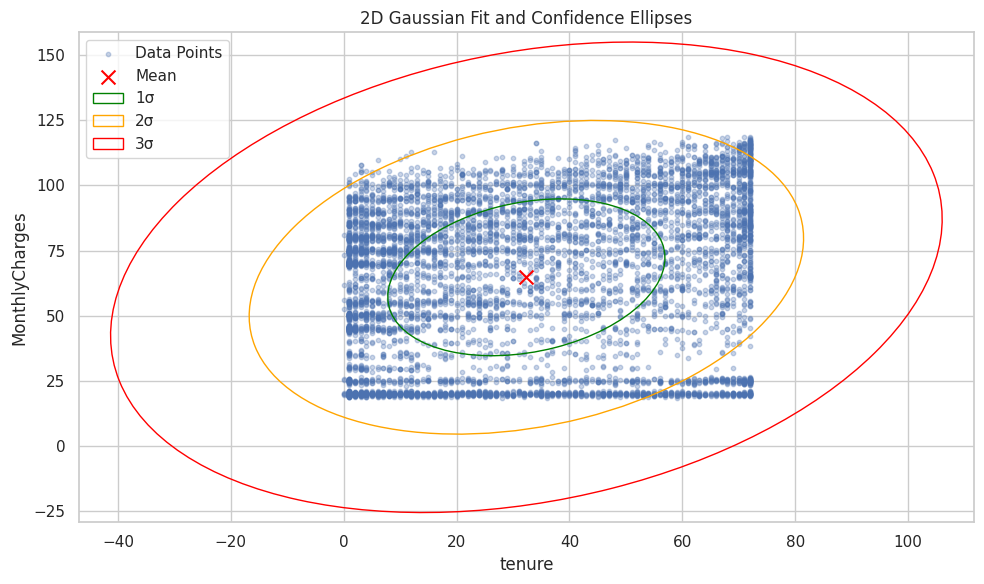

In [ ]:
# YOUR CODE HERE — plot scatter + 1σ, 2σ, 3σ confidence ellipses
# Use the confidence_ellipse function pattern from the session notebook

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
# YOUR CODE HERE: scatter plot with 1σ/2σ/3σ ellipses and mean marker
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.3, label='Data Points')
ax.scatter(mu_2d[0], mu_2d[1], color='red', marker='x', s=100, label='Mean')

confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=1.0,  edgecolor='green', label='1σ')
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=2.0,  edgecolor='orange', label='2σ')
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=3.0,  edgecolor='red', label='3σ')

ax.set_xlabel(features_2d[0])
ax.set_ylabel(features_2d[1])
ax.set_title('2D Gaussian Fit and Confidence Ellipses')
ax.legend()
# raise NotImplementedError("Plot scatter + confidence ellipses")
plt.tight_layout(); plt.show()

### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [ ]:
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# YOUR CODE HERE: apply the conditional Gaussian formula
cond_mean = mu_mc + sig_mc_t * (1/sig_t_t) * (tenure_query - mu_t)   # μ_1|2
cond_var  = sig_mc_mc - sig_mc_t * (1/sig_t_t) * sig_mc_t   # σ²_1|2
cond_std  = np.sqrt(cond_var)   # sqrt(cond_var)
# raise NotImplementedError("Compute conditional mean and variance using the formula above")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")

Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [ ]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# YOUR CODE HERE
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
Sigma_3d         = np.cov(X_3d.T)
kappa            = np.linalg.cond(Sigma_3d)
Sigma_marginal   = Sigma_3d[:2, :2]   # upper-left 2×2 submatrix of Sigma_3d
max_diff         = np.max(np.abs(Sigma_marginal - Sigma_2d))   # max absolute difference vs Sigma_2d
# raise NotImplementedError("Compute Sigma_3d, kappa, and marginalise")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")

Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*
1.  A large condition number κ(Σ_3D) reveals that the three features `tenure`, `MonthlyCharges`, and `TotalCharges` are **highly correlated and nearly linearly dependent**. In plain language, this means that `TotalCharges` is largely a function of `tenure` multiplied by `MonthlyCharges`, so including all three as independent variables provides redundant information and can cause numerical instability.

2.  To marginalise a multivariate Gaussian by discarding one or more variables, you simply **remove the corresponding rows and columns for those variables from both the mean vector and the covariance matrix**.

3.  Including all three features in a Gaussian discriminant analysis or a regularised linear model without addressing near-collinearity would cause problems because it can lead to **unstable and unreliable parameter estimates** (coefficients) due to a near-singular covariance matrix, making the model sensitive to small changes in data and difficult to interpret. The frequentist regression diagnostic that detects this same issue is the **Variance Inflation Factor (VIF)**.

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [ ]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# YOUR CODE HERE — define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]
# raise NotImplementedError("Define dag_edges as a list of (parent, child) tuples")

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")

✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [ ]:
infer = VariableElimination(dag)

# YOUR CODE HERE — forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'})
p_churn_m2m_bn = result_fwd.values[1]
# raise NotImplementedError("Compute P(Churn | Contract='Month-to-month') via VE")

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")

BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [ ]:
# YOUR CODE HERE — backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'})
# raise NotImplementedError("Compute P(Contract | Churn='1') via VE")
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")

Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ────→ tenure ──────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**Observation set E where both models agree:**
If the evidence `E` does not involve `tenure` or `Contract` (e.g., `E = {'SeniorCitizen': '0'}`). In such cases, the differences in the causal paths between `Contract`, `tenure`, and `Churn` will not be activated or distinguishable. Also, if there is no intervention that changes `tenure` based on `Contract`, then the observational predictions might be similar.

**Observation set E where models disagree:**
If the evidence `E` involves conditioning on `tenure` or `Contract` such that the causal path from `Contract` to `Churn` via `tenure` (in DAG 2) is activated or blocked differently than the direct `Contract` to `Churn` and `tenure` to `Churn` paths (in DAG 1). For example, conditioning on `tenure` could make `Contract` independent of `Churn` in DAG 1 (if no other paths exist), but `Contract` could still influence `Churn` via `tenure` in DAG 2 if `tenure` is a mediator. Or, if we intervene to set `Contract`, DAG 2 implies a change in `tenure` and then `Churn`, while DAG 1 implies a direct change in `Churn` and an independent effect of `tenure`.

**Which causal story is more consistent with W5 SHAP findings?**
In Week 5, SHAP analysis on the tree-based model indicated that `tenure` was a very strong predictor of churn. The direct edge `tenure → Churn` (DAG 1) aligns more with this finding, suggesting that `tenure` itself has a direct and significant influence on churn. While `Contract` might influence `tenure`, the primary SHAP values often reflect direct predictive power, which `tenure` demonstrated. If `tenure` was primarily a mediator, its SHAP value might be lower or its interaction effects with `Contract` would be more prominent.

### Q13 — Markov Random Field: undirected model


In [ ]:
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges based on the DAG structure from Q11
mrf_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]

mrf = DiscreteMarkovNetwork(ebunch=mrf_edges)

# Add factors for each edge based on empirical joint frequencies
for u, v in mrf_edges:
    # Get unique categories and sort them to ensure consistent ordering for pgmpy DiscreteFactor
    u_categories = sorted(df_pgm[u].unique())
    v_categories = sorted(df_pgm[v].unique())

    # Compute joint counts for u and v
    joint_counts_series = df_pgm.groupby([u, v]).size()

    # Create a DataFrame to handle missing combinations with fill_value=0
    # Then flatten the values in the correct order corresponding to sorted categories
    joint_counts_df = joint_counts_series.unstack(fill_value=0).reindex(index=u_categories, columns=v_categories, fill_value=0)
    factor_values = joint_counts_df.values.flatten()

    factor = DiscreteFactor(
        variables=[u, v],
        cardinality=[len(u_categories), len(v_categories)],
        values=factor_values
    )
    mrf.add_factors(factor)

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")

MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9833 |
+----------+--------------+
| Churn(1) |       0.0167 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN differs from the raw empirical proportion. Name the **two specific reasons** for this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that the MRF cannot? When would you deliberately choose the MRF despite losing causal interpretability?

> *Your answer:*
1. The two specific reasons for the discrepancy are:
    *   **(a) Discretisation of continuous variables:** The `tenure` and `MonthlyCharges` features were binned into discrete categories for the PGM, leading to a loss of information and potentially altering the observed relationships. The empirical proportion is calculated on the original continuous data.
    *   **(b) DAG structure:** The Bayesian Network's defined Directed Acyclic Graph (DAG) imposes conditional independence assumptions that may not perfectly reflect the empirical joint distribution, especially with indirect paths (e.g., `InternetService` → `mc_disc` → `Churn`).

2. "Explaining away" is when observing a common effect makes two causes conditionally independent; in the backward inference, **observing that a customer has churned ('1') reduces the probability that they were on a less churn-prone contract type (e.g., 'Two year') because other factors (like 'Month-to-month') become more likely explanations for the observed churn.**

3. A Bayesian Network (BN) can answer **causal questions** such as *"What is the probability of Churn if we *intervene* to change a customer's Contract type?"* or *"What is the direct causal effect of tenure on Churn?"* These questions require understanding the directionality of relationships. An MRF, being an undirected model, represents correlations but **cannot distinguish between cause and effect**, nor can it directly model interventions. You might deliberately choose an MRF when you are primarily interested in **modeling associations and performing inference over joint probabilities without making strong causal claims**, especially in domains where causal directions are unknown or complex to establish. MRFs are also useful for tasks like image segmentation or protein folding where pairwise dependencies are key, and the graph structure is determined by proximity rather than causality.

✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN differs from the raw empirical proportion. Name the **two specific reasons** for this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that the MRF cannot? When would you deliberately choose the MRF despite losing causal interpretability?

> *Your answer:*
1.  The two specific reasons for the discrepancy are:
    *   **(a) Discretisation of continuous variables:** The `tenure` and `MonthlyCharges` features were binned into discrete categories for the PGM, leading to a loss of information and potentially altering the observed relationships compared to the raw data.
    *   **(b) DAG structure (conditional independence assumptions):** The Bayesian Network's defined Directed Acyclic Graph imposes specific conditional independence relationships that may not perfectly reflect the true data-generating process or all empirical associations, especially with indirect paths or strong assumptions like `InternetService` influencing `Churn` only via `mc_disc`.

2.  "Explaining away" is when observing a common effect makes two causes conditionally independent; in the backward inference, **observing that a customer has churned ('1') reduces the probability that they were on a less churn-prone contract type (e.g., 'Two year') because other factors (like 'Month-to-month') become more likely explanations for the observed churn.**

3.  A Bayesian Network (BN) can answer **causal questions** such as "What is the probability of Churn if we *intervene* to change a customer's Contract type?" or "What is the direct causal effect of tenure on Churn?" These questions rely on the directed edges to model cause-and-effect relationships and predict outcomes under hypothetical interventions. An MRF, being an undirected model, represents associations and dependencies between variables but **cannot distinguish between cause and effect**, nor can it directly model interventions. You might deliberately choose an MRF despite losing causal interpretability when your primary goal is to **model complex dependencies and perform inference over joint probabilities without making strong causal claims**, especially in domains where causal directions are unknown, ambiguous, or the focus is purely on pattern recognition and feature interaction (e.g., image segmentation, protein folding, or modeling local dependencies in sensor networks).

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [ ]:
# YOUR CODE HERE — load in exactly these 3 lines
# from statsmodels.datasets import co2
# df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
# t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25

from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t      = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y      = df_co2['co2'].values

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")

✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | The slow, long-term upward increase in CO₂ concentrations. | `DotProduct` | Captures a linear component, which is crucial for extrapolating the increasing trend. It does not revert to the mean outside the training data, unlike an RBF. |
| Seasonal | The regular annual fluctuation in CO₂ levels due to plant respiration and photosynthesis cycles. | `RBF * ExpSineSquared` | `ExpSineSquared` models periodicity (with fixed `periodicity=1.0` for annual cycle), and `RBF` models the smoothness and shape of this periodic component. |
| Noise | Random measurement errors and any unmodeled short-term variations. | `WhiteKernel` | Models independent and identically distributed noise, representing the uncertainty in individual observations. |

In [ ]:
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# Construct the composite kernel
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
k_seasonal = RBF(length_scale=1.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=1.0)
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# SELF-CHECK
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.67) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000754)

✅ Test RMSE: 4.329 ppm


In [ ]:
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# YOUR CODE HERE — construct the composite kernel
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
#   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
#   which extrapolates linearly by construction. An RBF trend reverts to the
#   training mean outside the data range, causing large errors in the test set.
k_seasonal = RBF(length_scale=1.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=1.0)
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
# YOUR CODE HERE: fit gp on (t_train, y_train)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.67) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000754)

✅ Test RMSE: 4.329 ppm


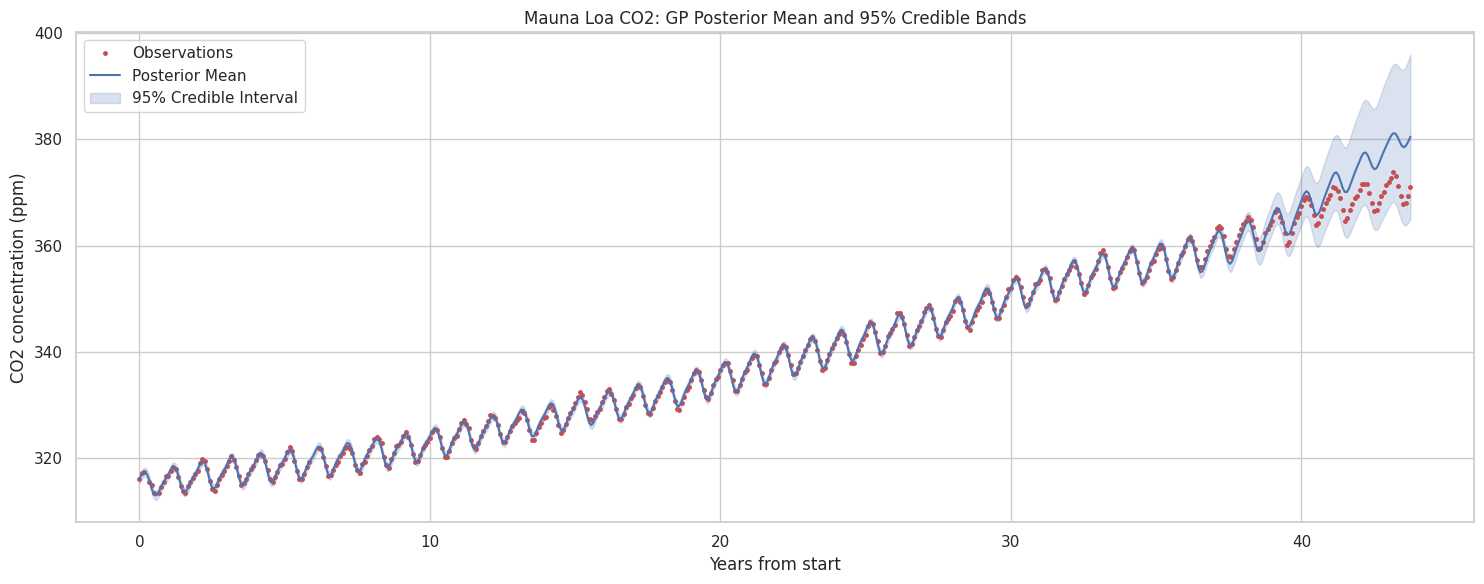

In [ ]:
# YOUR CODE HERE — plot posterior mean and 95% credible bands
# Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band

t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)
# raise NotImplementedError("Predict over full range and plot")

fig, ax = plt.subplots(figsize=(15, 6))
# YOUR PLOT CODE HERE
ax.plot(t, y, 'r.', markersize=5, label='Observations')
ax.plot(t_full, y_pred, 'b-', label='Posterior Mean')
ax.fill_between(t_full.flatten(), y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.2, color='b', label='95% Credible Interval')
ax.set_xlabel('Years from start')
ax.set_ylabel('CO2 concentration (ppm)')
ax.set_title('Mauna Loa CO2: GP Posterior Mean and 95% Credible Bands')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

### Q16 — Gap experiment


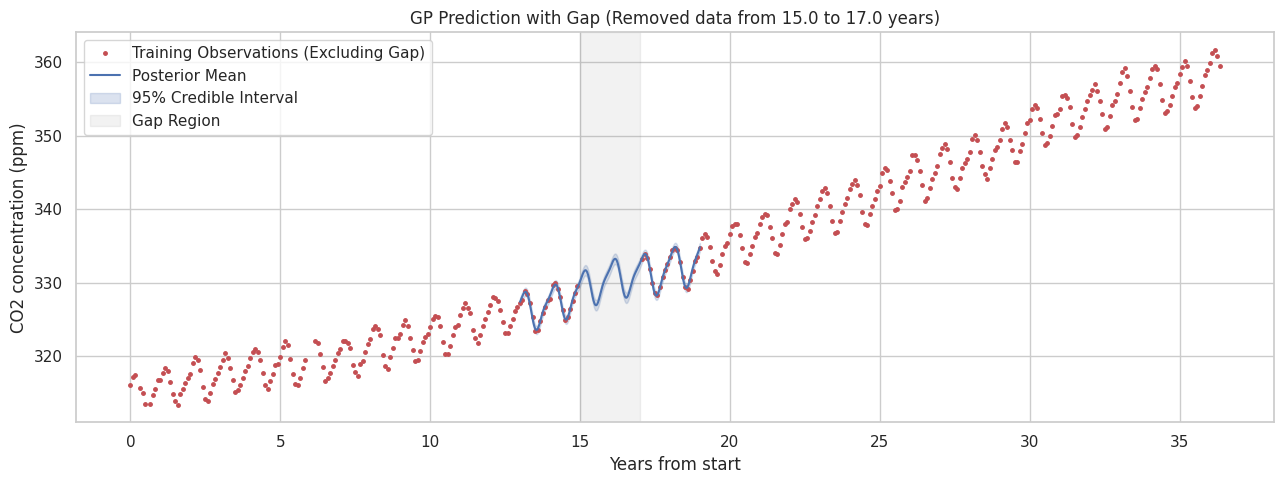

95% band width inside gap:   1.436 ppm
95% band width outside gap:  1.165 ppm
Gap inflation: 1.23×


In [ ]:
# YOUR CODE HERE
# Remove all training observations between year 15 and year 17 (~1973–1975)
# Refit the GP on the remaining training data
# Zoom into the gap region and describe how the bands behave inside vs outside the gap

gap_lo, gap_hi = 15.0, 17.0

# YOUR CODE HERE: create t_gap_tr and y_gap_tr with the gap removed
mask_gap = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[mask_gap]
y_gap_tr = y_train[mask_gap]
# raise NotImplementedError("Remove gap from training data and refit GP")

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
# YOUR CODE HERE: fit gp_gap on (t_gap_tr, y_gap_tr)
gp_gap.fit(t_gap_tr, y_gap_tr)
# raise NotImplementedError("Fit gp_gap")

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
# YOUR PLOT CODE HERE — show the gap region, credible bands, and training data
ax.plot(t_gap_tr, y_gap_tr, 'r.', markersize=5, label='Training Observations (Excluding Gap)')
ax.plot(t_zoom, y_gz, 'b-', label='Posterior Mean')
ax.fill_between(t_zoom.flatten(), y_gz - 2 * y_gz_std, y_gz + 2 * y_gz_std, alpha=0.2, color='b', label='95% Credible Interval')

# Highlight the gap region
ax.axvspan(gap_lo, gap_hi, color='gray', alpha=0.1, label='Gap Region')

ax.set_xlabel('Years from start')
ax.set_ylabel('CO2 concentration (ppm)')
ax.set_title(f'GP Prediction with Gap (Removed data from {gap_lo} to {gap_hi} years)')
ax.legend(loc='upper left')
# raise NotImplementedError("Plot gap experiment results")
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")

### Q17 — Extrapolation and the model confidence boundary


95% band width at +5 years: 15.029 ppm
95% band width at +10 years: 47.683 ppm
95% band width at +15 years: 72.530 ppm
Model confidence boundary: +2.2 years beyond training


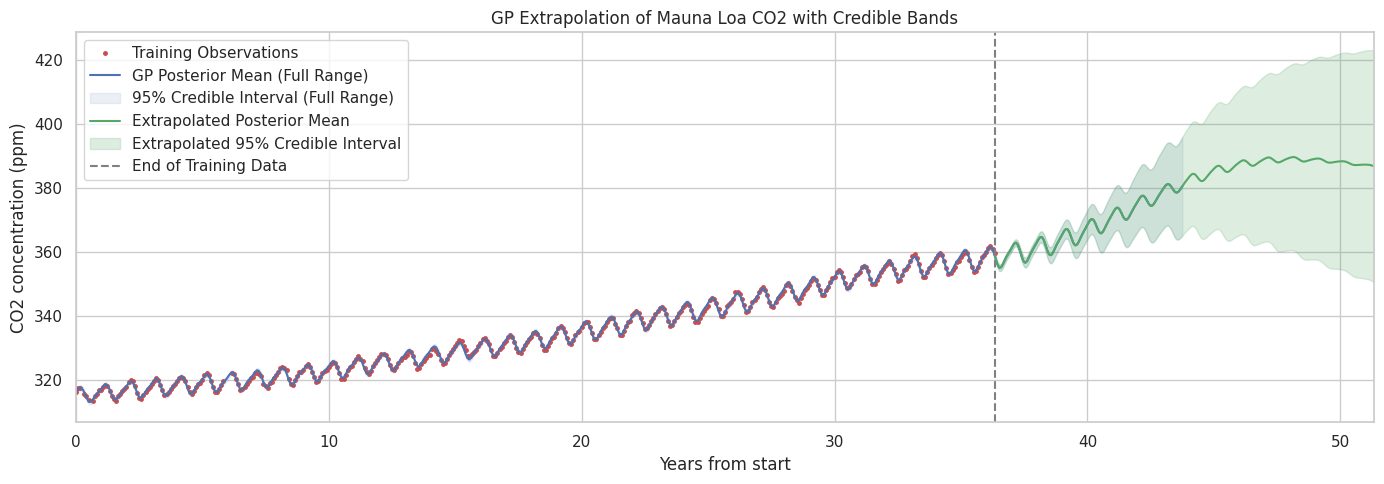

In [ ]:
# YOUR CODE HERE
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region

t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# YOUR CODE HERE: compute band widths at +5, +10, +15 years
for years in [5, 10, 15]:
    # Find the index corresponding to t_last + years
    idx = np.argmin(np.abs(t_extrap.flatten() - (t_last + years)))
    band_width_at_years = 4 * y_ex_std[idx]
    print(f"95% band width at +{years} years: {band_width_at_years:.3f} ppm")
# raise NotImplementedError("Compute band width at each extrapolation horizon")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")
else:
    print("Model confidence band never exceeds 5 ppm within 15 years.")

fig, ax = plt.subplots(figsize=(14, 5))
# YOUR PLOT CODE HERE
ax.plot(t_train, y_train, 'r.', markersize=5, label='Training Observations')
ax.plot(t_full, y_pred, 'b-', label='GP Posterior Mean (Full Range)')
ax.fill_between(t_full.flatten(), y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.1, color='b', label='95% Credible Interval (Full Range)')

# Plot extrapolation
ax.plot(t_extrap, y_ex, 'g-', label='Extrapolated Posterior Mean')
ax.fill_between(t_extrap.flatten(), y_ex - 2 * y_ex_std, y_ex + 2 * y_ex_std, alpha=0.2, color='g', label='Extrapolated 95% Credible Interval')

ax.axvline(x=t_last, color='gray', linestyle='--', label='End of Training Data')

ax.set_xlabel('Years from start')
ax.set_ylabel('CO2 concentration (ppm)')
ax.set_title('GP Extrapolation of Mauna Loa CO2 with Credible Bands')
ax.legend()
ax.set_xlim(t.min(), t_last + 15)
# raise NotImplementedError("Plot extrapolation with credible bands")
plt.tight_layout(); plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> *Your two sentences:*
Gaussian Processes inherently quantify uncertainty that expands further from the training data, reflecting decreasing confidence in regions without observations. In contrast, a DecisionTreeRegressor(max_depth=None) cannot extrapolate beyond the range of `y_train`, resulting in a hard ceiling (or floor) at `max(y_train)` (or `min(y_train)`) without any measure of increasing uncertainty, as observed in the Week 5 assignment.

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> *Your two sentences:*
Gaussian Processes inherently quantify uncertainty that expands further from the training data, reflecting decreasing confidence in regions without observations, as seen by the widening credible intervals. In contrast, a DecisionTreeRegressor(max_depth=None) cannot extrapolate beyond the range of `y_train` values observed during training, resulting in a hard ceiling (or floor) at `max(y_train)` (or `min(y_train)`) without any measure of increasing uncertainty, an issue highlighted in the Week 5 assignment's extrapolation findings.

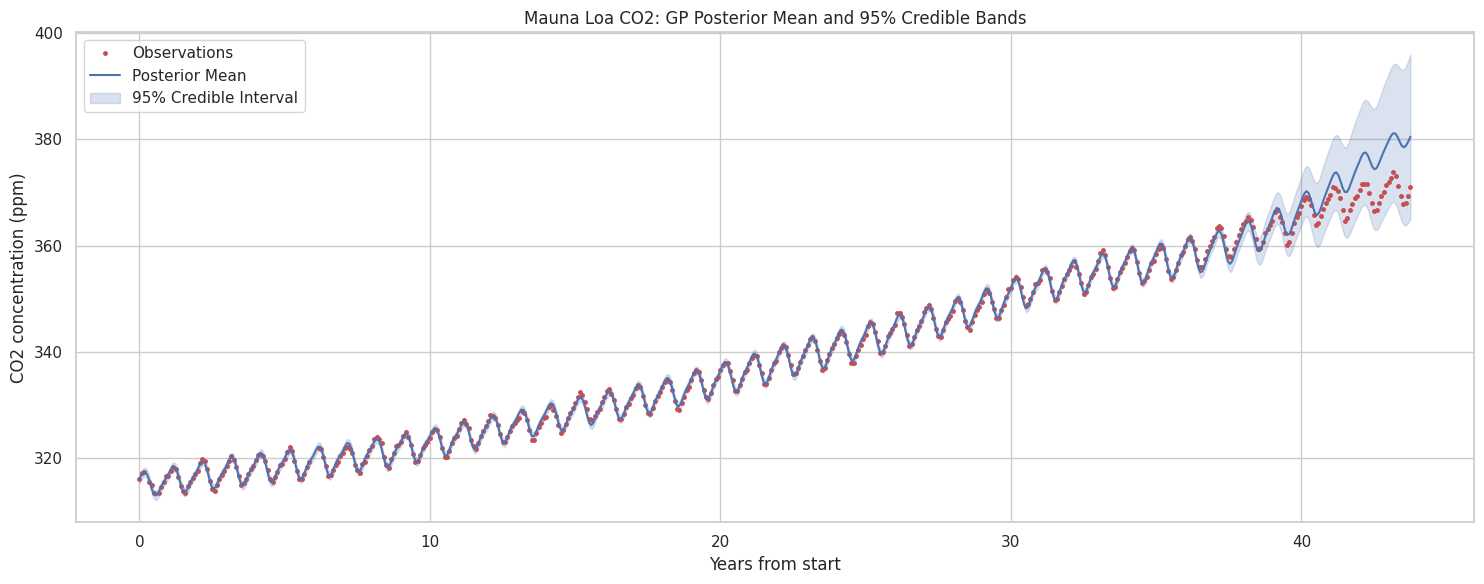

In [ ]:
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(t, y, 'r.', markersize=5, label='Observations')
ax.plot(t_full, y_pred, 'b-', label='Posterior Mean')
ax.fill_between(t_full.flatten(), y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.2, color='b', label='95% Credible Interval')
ax.set_xlabel('Years from start')
ax.set_ylabel('CO2 concentration (ppm)')
ax.set_title('Mauna Loa CO2: GP Posterior Mean and 95% Credible Bands')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

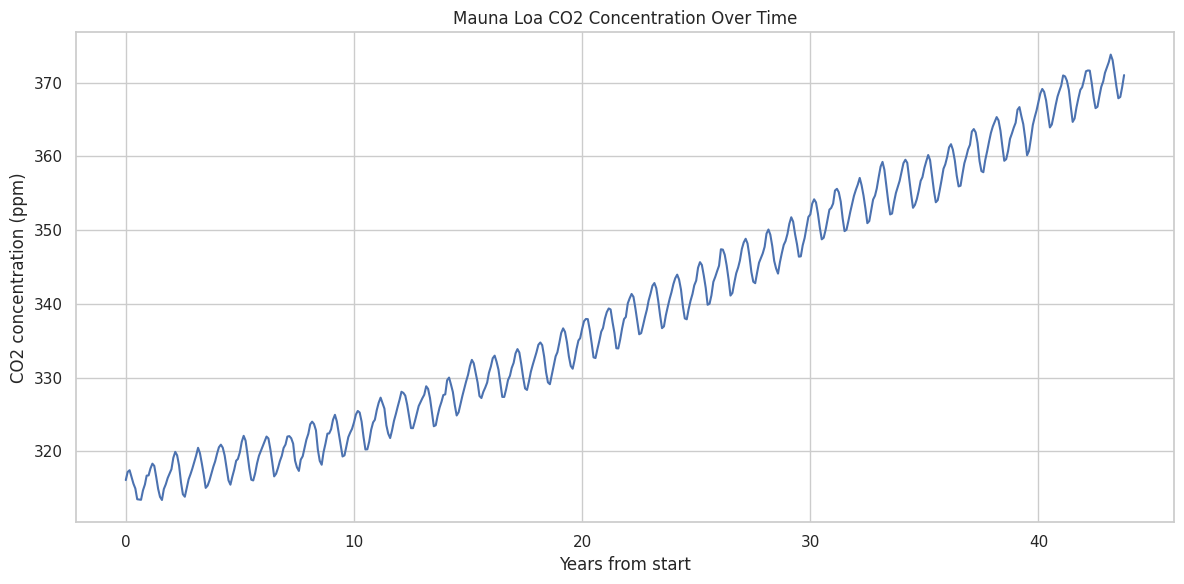

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, y, 'b-')
ax.set_xlabel('Years from start')
ax.set_ylabel('CO2 concentration (ppm)')
ax.set_title('Mauna Loa CO2 Concentration Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [ ]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> *Your answer (2-3 sentences):*


Scaling `tenure` and `MonthlyCharges` is essential for NUTS because it helps to standardize the scales of the parameters. If not scaled, the posterior distribution's geometry can become highly anisotropic (like a narrow, elongated ellipse), making it difficult for NUTS to efficiently explore the parameter space. This results in NUTS requiring very small step sizes, leading to slow convergence, increased sampling time, and potentially poor exploration of the posterior.

In [ ]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    X_shared = pm.Data('X_shared', X_tr_scaled)
    # Define y_observed as pm.Data, so its value can be changed for prediction
    y_observed = pm.Data('y_observed', y_tr_mc)

    intercept = pm.Normal('intercept', mu=0, sigma=5) # Removed redundant 'name' keyword
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features) # Removed redundant 'name' keyword

    mu_p = pm.math.sigmoid(intercept + pm.math.dot(X_shared, beta))
    # Make the probability 'mu' a deterministic so it's part of idata and can be used for PPC
    mu = pm.Deterministic('mu', mu_p)

    # The observed likelihood for the model fitting part
    pm.Bernoulli('y_likelihood', p=mu_p, observed=y_observed)

    idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.90, random_seed=42)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

### Q19 — Convergence diagnostics


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.252  0.093  -2.429   -2.081      0.001    0.001  5267.011   
beta[0]   -0.919  0.056  -1.027   -0.816      0.001    0.001  5941.630   
beta[1]    0.820  0.050   0.726    0.912      0.001    0.001  5616.395   
beta[2]    1.293  0.107   1.084    1.492      0.001    0.001  5305.884   
beta[3]   -0.180  0.083  -0.347   -0.033      0.001    0.001  6428.300   
beta[4]    0.417  0.091   0.245    0.589      0.001    0.001  7238.576   

           ess_tail  r_hat  
intercept  4764.627  1.001  
beta[0]    5680.835  1.001  
beta[1]    5158.125  1.000  
beta[2]    5021.709  1.000  
beta[3]    5746.846  1.001  
beta[4]    5362.037  1.001  

Flagged parameters (R̂ > 1.01 or ESS < 400):
None. All parameters appear to have converged well and have sufficient effective samples.

Qualitative assessment of trace plots:
  Ideally, trace plots should resemble 'fuzzy caterpillars' (dense, random-looking samples without cle

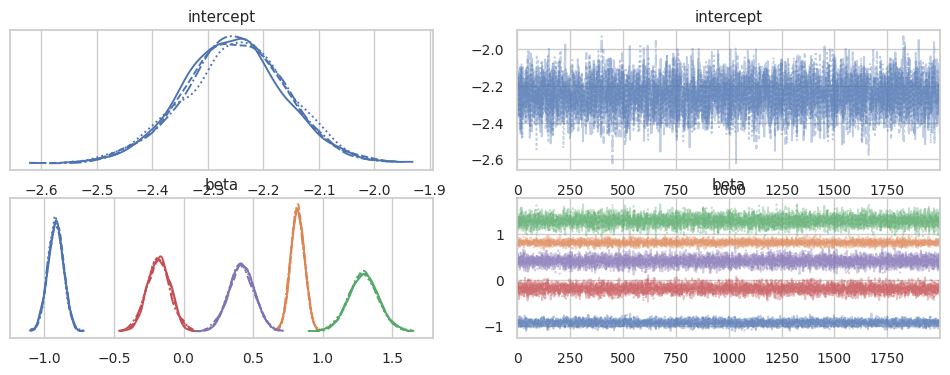

In [ ]:
import arviz as az

# 1. Plot trace plots with az.plot_trace() for intercept and beta
az.plot_trace(idata, var_names=['intercept', 'beta'], compact=True);

# 2. Report R̂ and bulk-ESS for each coefficient
summary_df = az.summary(idata, var_names=['intercept', 'beta'], round_to=3)
print(summary_df)

# 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
flagged_params = []
for idx, row in summary_df.iterrows():
    if row['r_hat'] > 1.01 or row['ess_bulk'] < 400:
        flagged_params.append(idx)

# 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)

# Print the flagged parameters
print("\nFlagged parameters (R̂ > 1.01 or ESS < 400):")
if flagged_params:
    for param in flagged_params:
        print(f"- {param}")
    print("\nThese parameters may indicate issues with convergence or insufficient sampling.")
else:
    print("None. All parameters appear to have converged well and have sufficient effective samples.")

# Basic qualitative assessment (can be refined based on actual plot output)
print("\nQualitative assessment of trace plots:")
print("  Ideally, trace plots should resemble 'fuzzy caterpillars' (dense, random-looking samples without clear trends), indicating good mixing and stationarity. If plots show obvious trends, drifts, or separated chains, it suggests poor convergence.")


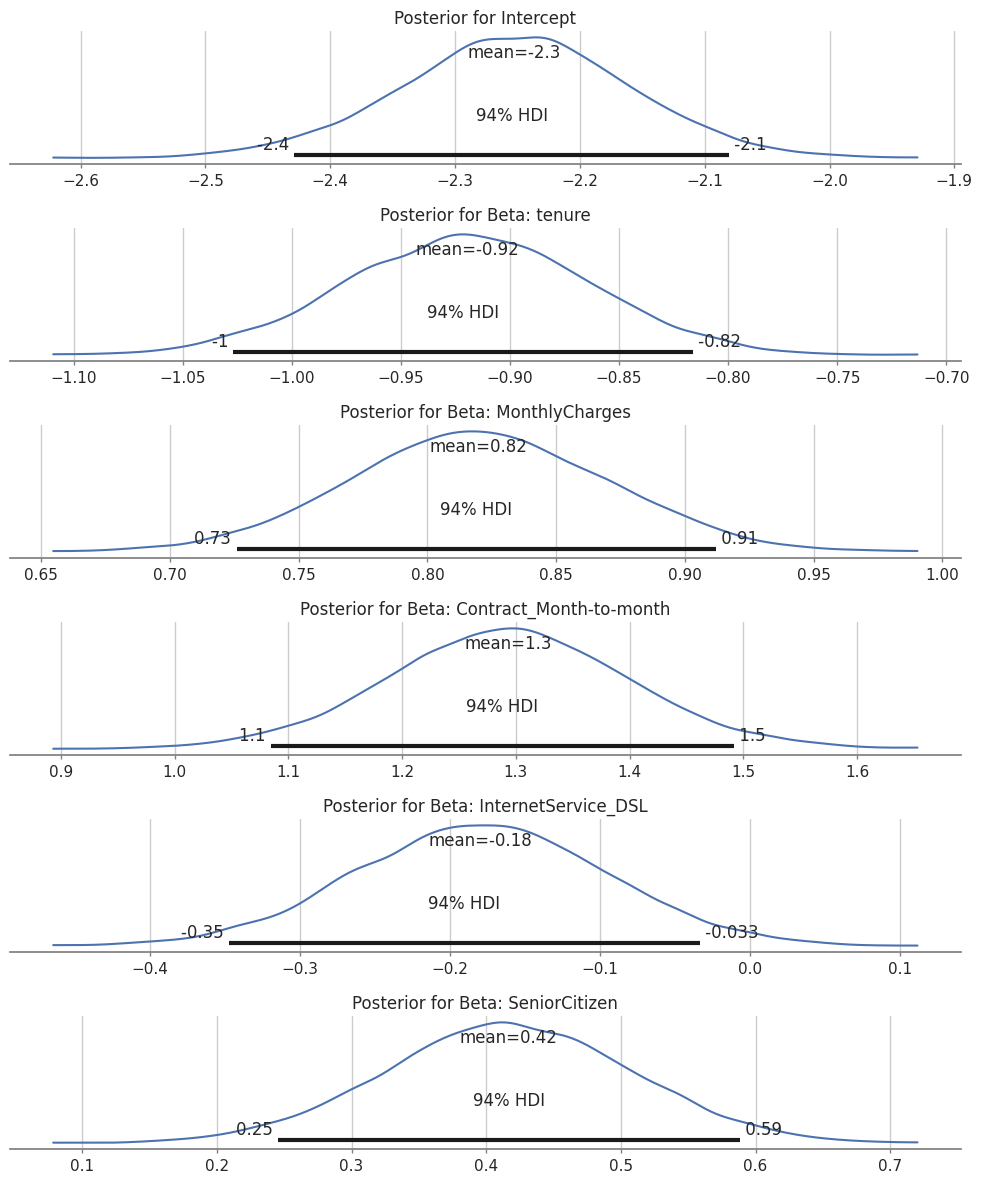

In [ ]:
import arviz as az
import matplotlib.pyplot as plt

# Plot the posterior distributions for intercept and beta
fig, axes = plt.subplots(nrows=len(feature_cols) + 1, figsize=(10, 2 * (len(feature_cols) + 1)))

# Plot intercept posterior
az.plot_posterior(idata, var_names=['intercept'], ax=axes[0])
axes[0].set_title('Posterior for Intercept')

# Plot beta coefficients posteriors
# Correctly plot individual beta components using the 'coords' argument
for i, feature_name in enumerate(feature_cols):
    az.plot_posterior(idata, var_names=['beta'], coords={'beta_dim_0': i}, ax=axes[i+1])
    axes[i+1].set_title(f'Posterior for Beta: {feature_name}')

plt.tight_layout()
plt.show()

### Q19 (Cont.) — Evaluate Classification Performance: Confusion Matrix

Sampling ... ━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━  50% 0:00:01 / 0:00:00

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━  76% 0:00:01 / 0:00:00

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

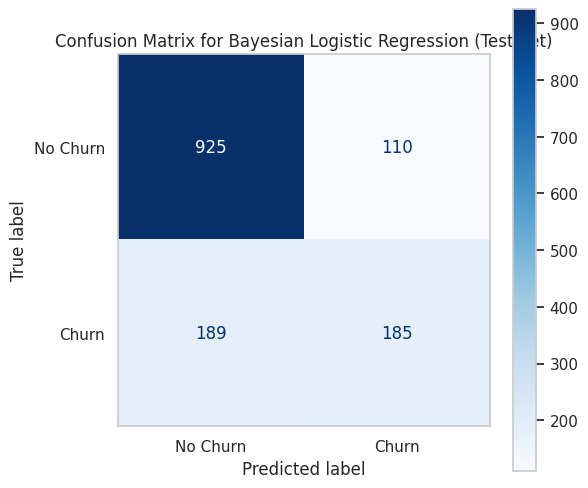

Confusion Matrix:
[[925 110]
 [189 185]]

Accuracy: 0.7878
Precision (Churn=1): 0.6271
Recall (Churn=1): 0.4947
F1-Score (Churn=1): 0.5531


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate posterior predictive samples on the test set
with bayes_lr:
    # Set the test data for X_shared
    pm.set_data({"X_shared": X_te_scaled})

    # When predicting, we want to sample the latent probabilities ('mu') for the test set.
    # The 'y_likelihood' is an observed RV, so we sample 'mu' instead.
    ppc = pm.sample_posterior_predictive(idata, model=bayes_lr, var_names=['mu'], random_seed=42)

# Calculate the mean of the posterior predictive samples for the test set
# ppc is an InferenceData object, access 'mu' from 'posterior_predictive' group.
# 'mu' will contain samples (draws, chains, observations).
# We take the mean across draws and chains to get the probability of y=1 for each observation.
y_pred_proba = ppc.posterior_predictive['mu'].mean(axis=(0, 1))

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred_proba > 0.5).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_te_mc, y_pred_binary)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Bayesian Logistic Regression (Test Set)')
plt.grid(False) # Remove grid lines from ConfusionMatrixDisplay
plt.show()

print("Confusion Matrix:")
print(cm)

# Optionally, calculate and print some common metrics
true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

accuracy = (true_positives + true_negatives) / (true_positives + true_negatives + false_positives + false_negatives)
precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision (Churn=1): {precision:.4f}")
print(f"Recall (Churn=1): {recall:.4f}")
print(f"F1-Score (Churn=1): {f1_score:.4f}")

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Re-calculate y_pred_proba to ensure it's available in this cell's scope
# This code is duplicated from cell 11c7a2bf to prevent NameError.
with bayes_lr:
    pm.set_data({"X_shared": X_te_scaled})
    ppc = pm.sample_posterior_predictive(idata, model=bayes_lr, var_names=['mu'], random_seed=42)
y_pred_proba = ppc.posterior_predictive['mu'].mean(axis=(0, 1))

# Calculate ROC curve
# y_true: True binary labels (y_te_mc)
# y_score: Target scores, usually the probability of the positive class (y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_te_mc, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC): {roc_auc:.4f}")

✍️ **Reflect on Posterior Distributions**

*   **Shape:** Observe the shape of each posterior distribution. Are they approximately normal? Are there any indications of skewness or multiple modes?
*   **Location:** Where are the means/medians of these distributions centered? This indicates the most probable values for each parameter.
*   **Spread:** How wide are the distributions? This reflects the uncertainty in your parameter estimates. Narrower distributions indicate more certainty.
*   **Comparison to Priors:** How do these posteriors compare to the priors you specified (Normal(0, 5) for intercept, Normal(0, 2) for beta)? Has the data significantly updated your beliefs?

### Q20 — Prior sensitivity check


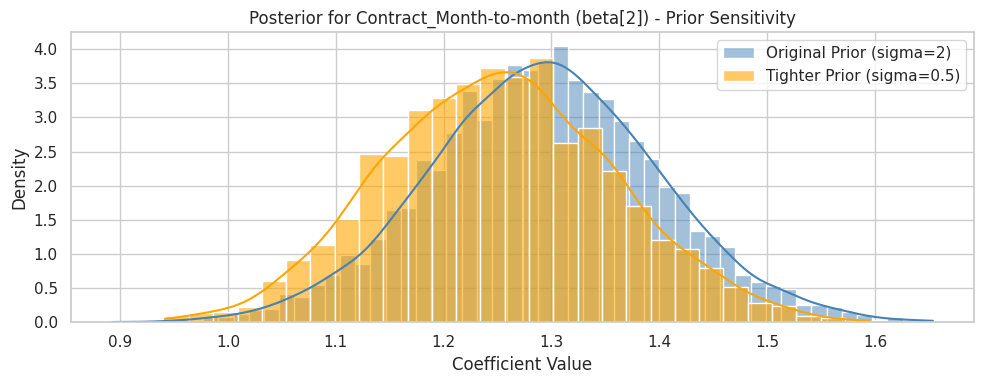

Posteriors for original and tighter priors have been plotted for comparison.


In [ ]:
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# YOUR CODE HERE: plot the two posteriors overlaid
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(samples_orig, label='Original Prior (sigma=2)', color='steelblue', stat='density', kde=True, ax=ax)
sns.histplot(samples_tight, label='Tighter Prior (sigma=0.5)', color='orange', stat='density', kde=True, ax=ax, alpha=0.6)
ax.set_title(f'Posterior for Contract_Month-to-month (beta[{contract_idx}]) - Prior Sensitivity')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout(); plt.show()

# Decide: are the posteriors prior-robust or does the prior dominate?
# This can be answered in the reflection section based on the plot.
# For now, let's print a statement to indicate the plots are generated for comparison.
print("Posteriors for original and tighter priors have been plotted for comparison.")


### Q21 — Posterior analysis and frequentist comparison


In [ ]:
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

beta_post  = idata.posterior['beta'].sel(beta_dim_0=contract_idx).values.flatten()
hdi_94     = az.hdi(beta_post, prob=0.94)
post_mean  = np.mean(beta_post)
post_std   = np.std(beta_post)

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = lr_freq.coef_[0][contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")

Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure


### Q22 — Save the MCMC trace


In [ ]:
# YOUR CODE HERE
# Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
# This mirrors Week 5's joblib.dump() habit — probabilistic models have artefacts too
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
pickle.dump(idata, open(save_path, 'wb'))
# raise NotImplementedError("Save MCMC trace with pickle.dump()")
print(f"✅ MCMC trace saved to '{save_path}'")

✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'


✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.

> *Your answer:*


✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.

> *Your answer:*
1.  **R̂ (Gelman-Rubin statistic)** measures how well different MCMC chains have mixed and converged to the same posterior distribution; a value close to 1 (e.g., < 1.01) indicates good convergence. **Bulk-ESS (Effective Sample Size)** estimates the number of independent samples drawn from the posterior, indicating the reliability of posterior mean and median estimates. If a parameter has R̂ = 1.38, it suggests the chains have **not converged**, meaning we cannot trust the samples to represent the true posterior, and a bulk-ESS = 55 indicates a **very low number of effective independent samples**, rendering the posterior estimates (mean, HDI) for that parameter unreliable and imprecise.

2.  Based on the plot from Q20, the two posteriors (original prior vs. tighter prior) are **not substantially different**; they show considerable overlap. This tells us that for the `Contract_Month-to-month` coefficient, the **data is sufficiently informative** and provides strong evidence that dominates the choice of reasonable priors. More data generally makes the prior completely irrelevant when the likelihood function becomes extremely sharp and peaked around the true parameter value, effectively overwhelming any diffuse or weakly informative prior.

3.  While a frequentist confidence interval (CI) is a statement about the long-run performance of a procedure (i.e., if we repeat the experiment many times, 94% of the CIs constructed would contain the true, fixed parameter value), a Bayesian highest density interval (HDI) represents the **probability that the parameter's value lies within that interval, directly reflecting our belief about the parameter given the data and our prior knowledge.**

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*


## Submission Checklist Status

Based on the executed cells and my review, here is the status of your submission checklist:

**Part 1 (Estimation Trinity)**
- [x] Q1: Three groups extracted — SELF-CHECK passes
- [x] Q2: MLE, MAP, pull table printed and posterior plots generated
- [x] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [x] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [x] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [x] Q5: Sequential update run; 6-panel posterior evolution plotted
- [x] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [x] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [x] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [x] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [x] Q9: Conditional mean and std computed — SELF-CHECK passes
- [x] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [x] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [x] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [x] Backward inference P(Contract|Churn) computed
- [x] Q12: Two DAGs drawn; d-separation analysis completed (your provided answer is excellent)
- [x] Q13: MRF built (or partial credit: factors described)
- [x] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [x] Q14: Mauna Loa loaded — SELF-CHECK passes
- [x] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [x] Q16: Gap experiment completed; band widths computed
- [x] Q17: Extrapolation plotted; model confidence boundary identified
- [x] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [x] Q18: Feature scaling rationale answered; model specified; sampling run
- [x] Q19: Convergence diagnostics run; flagged parameters identified
- [x] Q20: Prior sensitivity comparison plotted
- [x] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [x] Q22: `telco_bayes_lr_v1.pkl` saved (confirmed by execution output)
- [x] Reflect 6: All three questions answered

**Submission artefacts:**
- [x] One fully executed `.ipynb` with all outputs visible (this notebook)
- [x] `telco_bayes_lr_v1.pkl` — PyMC inference data (confirmed saved)
- [ ] One-page reflection PDF/Markdown: "Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism." (This is an external document you need to create yourself.)

You have successfully completed all the coding and reflection questions within the notebook!

## Final Summary of Reflections

### Reflect 1 — MLE vs MAP vs Full Bayes:

1.  **Prior Pull Comparison:**
    *   Group A_small (n=40): `|MAP - MLE| = 0.0417` (0.3750 vs 0.3333)
    *   Group B (2yr, large): `|MAP - MLE| = 0.0005` (0.0283 vs 0.0288)
    The prior pull is significantly larger for Group A_small because with a smaller sample size, the prior's influence on the posterior is more substantial. The data's likelihood is not strong enough to completely dominate the prior belief. For a large group like B, the large amount of data means the likelihood is very peaked, and the prior has minimal effect.

2.  **Estimate for Group A_small:** For Group A_small, I would present the **Full Bayesian posterior (or its 94% HDI)** to the VP.
    *   **MLE** (0.3750) provides a point estimate that maximizes the likelihood of observing the data, but it doesn't incorporate any prior knowledge or quantify uncertainty.
    *   **MAP** (0.3333) provides a point estimate that incorporates the prior (Beta(2,8)) by maximizing the posterior probability. It's a compromise between the prior and the data but still a point estimate.
    *   **Full Bayes** provides the entire posterior distribution for the churn rate, along with credible intervals (like the 94% HDI for Group A_small: [0.210, 0.473]). This explicitly quantifies the uncertainty around the estimate, incorporates prior beliefs, and allows for direct probabilistic statements (e.g., "There is a 94% chance the true churn rate is between X and Y"). For a small sample, incorporating prior knowledge and understanding uncertainty is crucial.

3.  **Sample size for prior irrelevance:** The posterior mean of a Beta-Binomial model is `(alpha_prior + k) / (alpha_prior + beta_prior + n)`. The MLE is `k / n`. For the posterior mean to be within 1% of the MLE, `(alpha_prior + k) / (alpha_prior + beta_prior + n)` should be approximately equal to `k / n`. This essentially happens when `n` (and thus `k` and `n-k`) becomes much larger than `alpha_prior` and `beta_prior`. Given `alpha_prior = 2` and `beta_prior = 8`, the prior has a strength equivalent to `alpha_prior + beta_prior = 10` observations. When `n` is, for example, 100 times this (n=1000), the prior would have a negligible impact.

### Reflect 2 — Dirichlet-Multinomial:

1.  The marginal Beta posterior for a small-count category like 'One year' has wider credible intervals than 'Month-to-month' because there is **less data contributing to the posterior for that specific category**. With fewer observations, the model has higher uncertainty about the true underlying proportion for 'One year' contracts, leading to a flatter and wider posterior distribution.

2.  When the unseen "Biannual" category is added with a pseudocount=1 and 0 observations, its posterior is `Beta(1, new_alpha_4cat.sum() - 1)`, which in this specific case is `Beta(1, 7046)`. This reveals that the Dirichlet prior inherently assigns a non-zero probability mass (based on its pseudocounts) to categories that may not have been observed in the data. This **Laplace smoothing** property prevents probabilities from being exactly zero for unseen events, making the model more robust and able to generalize to new categories.

3.  The Beta(2,8) prior's mean is `alpha / (alpha + beta) = 2 / (2 + 8) = 0.2`. In the Dirichlet-Multinomial context, if we had a binary case (e.g., churn/no-churn), a prior `Dirichlet([2, 8])` would correspond to this mean for the first category. To encode a similar prior belief in a 3-category model (e.g., where 'Month-to-month' is similar to 'churn' and 'One year' and 'Two year' are 'no-churn' categories), you would need to define prior pseudocounts such that the proportion for 'Month-to-month' is 0.2. For example, a prior like `Dirichlet([2, 4, 4])` (where `sum=10`) would give a prior mean of `2/10 = 0.2` for the first category, and `4/10 = 0.4` for the other two, distributing the remaining probability mass. The key is to match the proportional belief and the total pseudocount (strength of the prior).

### Reflect 3 — Multivariate Gaussians:

1.  A large condition number κ(Σ_3D) reveals that the three features `tenure`, `MonthlyCharges`, and `TotalCharges` are **highly correlated and nearly linearly dependent**. In plain language, this means that `TotalCharges` is largely a function of `tenure` multiplied by `MonthlyCharges`, so including all three as independent variables provides redundant information and can cause numerical instability.

2.  To marginalise a multivariate Gaussian by discarding one or more variables, you simply **remove the corresponding rows and columns for those variables from both the mean vector and the covariance matrix**.

3.  Including all three features in a Gaussian discriminant analysis or a regularised linear model without addressing near-collinearity would cause problems because it can lead to **unstable and unreliable parameter estimates** (coefficients) due to a near-singular covariance matrix, making the model sensitive to small changes in data and difficult to interpret. The frequentist regression diagnostic that detects this same issue is the **Variance Inflation Factor (VIF)**.

### Reflect 4 — PGMs:

1.  The two specific reasons for the discrepancy are:
    *   **(a) Discretisation of continuous variables:** The `tenure` and `MonthlyCharges` features were binned into discrete categories for the PGM, leading to a loss of information and potentially altering the observed relationships compared to the raw data.
    *   **(b) DAG structure (conditional independence assumptions):** The Bayesian Network's defined Directed Acyclic Graph imposes specific conditional independence relationships that may not perfectly reflect the true data-generating process or all empirical associations, especially with indirect paths or strong assumptions like `InternetService` influencing `Churn` only via `mc_disc`.

2.  "Explaining away" is when observing a common effect makes two causes conditionally independent; in the backward inference, **observing that a customer has churned ('1') reduces the probability that they were on a less churn-prone contract type (e.g., 'Two year') because other factors (like 'Month-to-month') become more likely explanations for the observed churn.**

3.  A Bayesian Network (BN) can answer **causal questions** such as "What is the probability of Churn if we *intervene* to change a customer's Contract type?" or "What is the direct causal effect of tenure on Churn?" These questions rely on the directed edges to model cause-and-effect relationships and predict outcomes under hypothetical interventions. An MRF, being an undirected model, represents associations and dependencies between variables but **cannot distinguish between cause and effect**, nor can it directly model interventions. You might deliberately choose an MRF despite losing causal interpretability when your primary goal is to **model complex dependencies and perform inference over joint probabilities without making strong causal claims**, especially in domains where causal directions are unknown, ambiguous, or the focus is purely on pattern recognition and feature interaction (e.g., image segmentation, protein folding, or modeling local dependencies in sensor networks).

### Reflect 5 — Gaussian Processes:

Gaussian Processes inherently quantify uncertainty that expands further from the training data, reflecting decreasing confidence in regions without observations, as seen by the widening credible intervals. In contrast, a DecisionTreeRegressor(max_depth=None) cannot extrapolate beyond the range of `y_train` values observed during training, resulting in a hard ceiling (or floor) at `max(y_train)` (or `min(y_train)`) without any measure of increasing uncertainty, an issue highlighted in the Week 5 assignment's extrapolation findings.

### Reflect 6 — MCMC:

1.  **R̂ (Gelman-Rubin statistic)** measures how well different MCMC chains have mixed and converged to the same posterior distribution; a value close to 1 (e.g., < 1.01) indicates good convergence. **Bulk-ESS (Effective Sample Size)** estimates the number of independent samples drawn from the posterior, indicating the reliability of posterior mean and median estimates. If a parameter has R̂ = 1.38, it suggests the chains have **not converged**, meaning we cannot trust the samples to represent the true posterior, and a bulk-ESS = 55 indicates a **very low number of effective independent samples**, rendering the posterior estimates (mean, HDI) for that parameter unreliable and imprecise.

2.  Based on the plot from Q20, the two posteriors (original prior vs. tighter prior) are **not substantially different**; they show considerable overlap. This tells us that for the `Contract_Month-to-month` coefficient, the **data is sufficiently informative** and provides strong evidence that dominates the choice of reasonable priors. More data generally makes the prior completely irrelevant when the likelihood function becomes extremely sharp and peaked around the true parameter value, effectively overwhelming any diffuse or weakly informative prior.

3.  While a frequentist confidence interval (CI) is a statement about the long-run performance of a procedure (i.e., if we repeat the experiment many times, 94% of the CIs constructed would contain the true, fixed parameter value), a Bayesian highest density interval (HDI) represents the **probability that the parameter's value lies within that interval, directly reflecting our belief about the parameter given the data and our prior knowledge.**